Ботов ае ки22-08б

# Задание 5. Применение линейной модели для задач классификации и регрессии.  
В работе используется датасет Car, подготовленный при выполнении практической работы 2.

## Часть 1. Линейный классификатор.  
## Порядок работы:  
### 1. Подключение библиотек

In [15]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

### 2. Загрузка датасета
В ходе выполнения Работы 2 была подготовлена обучающая выборка.  
Ее необходимо считать из файла. Для упрощения дальнейшей работы и проверки выведите информацию об обучающей выборке и первые 5 строк  .
По желанию можно вывести также базовые статитические метрик  и.

In [16]:
df = pd.read_csv("cars_onehot.csv")
df.head()

,Year,Distance,Engine_capacity(cm3),Transmission,Price(euro),Year_norm,Distance_log,Engine_capacity_log,Price_log,Distance_std,...,Style_Minivan,Style_Pickup,Style_SUV,Style_Sedan,Style_Universal,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid
0,2011.0,195000.0,1800.0,1,7750.0,0.756098,12.180760,7.496097,8.955577,0.397962,...,False,False,False,False,False,False,True,False,False,False
1,2014.0,135000.0,1500.0,0,8550.0,0.829268,11.813037,7.313887,9.053804,0.267627,...,False,False,False,False,True,False,False,False,False,False
2,1998.0,1.0,1400.0,0,2200.0,0.439024,0.693147,7.244942,7.696667,-3.673671,...,False,False,False,False,False,False,False,False,True,False
3,2012.0,110000.0,1500.0,0,6550.0,0.780488,11.608245,7.313887,8.787373,0.195041,...,False,False,False,False,True,False,False,False,False,False
4,2006.0,200000.0,1600.0,0,4100.0,0.634146,12.206078,7.378384,8.318986,0.406935,...,False,False,False,False,True,False,False,True,False,False


### 3. Классификация: подготовка данных для обучения и тестирования модели  
Подготовка тестовой и обучающей выборки.  
Целевой параметр (таргет) классификации: вид трансмиссии  .
Исходный датасет разделить на обучающую и тестовую выборки в соотношении 80% / 20  %.
Для обеих выборок отделить целевой параметр от признаков.

In [17]:
from sklearn.model_selection import train_test_split

car_features_train, car_features_valid = train_test_split(df, test_size=0.2, train_size=0.8, shuffle=False)

transmission_train = car_features_train['Transmission']
car_features_train = car_features_train.drop('Transmission', axis=1)

transmission_valid = car_features_valid['Transmission']
car_features_valid = car_features_valid.drop('Transmission', axis=1)

### 4. Создание линейного бинарного классификатора на базе модели перцептрона  
В работе предполагается использовать класс Perceptron из библиотеки scikit-learn, который представляет собой оболочку класса SGDClassifier с зафиксированными параметрами loss (функция оценки/ошибки) и Learning_rate (шаг по градиенту).  
[Описание класса Perceptron из библиотеки sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)

In [18]:
from sklearn.linear_model import Perceptron
classifier_pt = Perceptron(verbose=1)

### 5. Обучение классификатора

In [19]:
classifier_pt.fit(car_features_train, transmission_train)

-- Epoch 1
Norm: 3523467.06, NNZs: 115, Bias: -1525.000000, T: 27115, Avg. loss: 7485546900.376670
Total training time: 0.02 seconds.
-- Epoch 2
Norm: 5148494.36, NNZs: 116, Bias: -2380.000000, T: 54230, Avg. loss: 7030465202.530087
Total training time: 0.03 seconds.
-- Epoch 3
Norm: 6541098.88, NNZs: 116, Bias: -3077.000000, T: 81345, Avg. loss: 6981258805.957306
Total training time: 0.04 seconds.
-- Epoch 4
Norm: 7839271.28, NNZs: 116, Bias: -3642.000000, T: 108460, Avg. loss: 6877038553.468224
Total training time: 0.05 seconds.
-- Epoch 5
Norm: 9132087.28, NNZs: 115, Bias: -4184.000000, T: 135575, Avg. loss: 6779708776.943658
Total training time: 0.06 seconds.
-- Epoch 6
Norm: 10186789.29, NNZs: 116, Bias: -4631.000000, T: 162690, Avg. loss: 6725592406.020419
Total training time: 0.07 seconds.
-- Epoch 7
Norm: 11227811.24, NNZs: 115, Bias: -5038.000000, T: 189805, Avg. loss: 6678642920.065956
Total training time: 0.08 seconds.
-- Epoch 8
Norm: 12186137.56, NNZs: 116, Bias: -5418.000

Perceptron(verbose=1)

### 6. Тестирование классификатора

#### 6.1 Проверка работоспособности классификатора на обучающей выборке

In [20]:
train_quality = classifier_pt.score(car_features_train, transmission_train)
valid_quality = classifier_pt.score(car_features_valid, transmission_valid)
print(f'Точность на обучающей выборке: {train_quality}')
print(f'Точность на валидационной выборке: {valid_quality}')

Точность на обучающей выборке: 0.7950580859302969
Точность на валидационной выборке: 0.7951025224959434


**Значения выглядят правдоподобно. Значения на тренировочной и валидационной выборках близки, скорее всего, модель не переобучена. Точность на валидационной выборке чуть выше, но едва ли это критично.**

#### 6.2 Оценка работы классификатора по показателю "нулевая точность" - null_accuracy
Сравним точность полученной модели с null_accuracy - точностью, которой можно достичь, всегда предсказывая наиболее часто встречающийся класс.

In [39]:
baseline_acc = max(transmission_valid.value_counts()) / transmission_valid.value_counts().sum()
print(f"Точность модели на валидационной выборке: {valid_quality}")
print(f"Базовая точность (наивная): {baseline_acc}")

acc_ratio = valid_quality / baseline_acc
comparison = "выше" if acc_ratio > 1 else "ниже"
print(f"Точность модели {comparison} базовой в {acc_ratio if acc_ratio > 1 else 1/acc_ratio:.2f} раза(раз)")

Точность модели на валидационной выборке: 0.7951025224959434
Базовая точность (наивная): 0.5900575306092344
Точность модели выше базовой в 1.35 раза(раз)


**Модель можно считать неплохой, ведь её точность выше нулевой почти на 30%**

#### 6.3. Определение метрик качества модели
Построить матрицу ошибок и рассчитать основные метрики: Accuracy, Precision, Recall, Specificity.
Матрицу ошибок и метрики вывести Можно визуализировать матрицу ошибок с помощью тепловой карты..

In [22]:
from sklearn.metrics import confusion_matrix

def quality_report(actual, predicted):
    matrix = confusion_matrix(actual, predicted)
    tn, fp, fn, tp = matrix.ravel()

    acc_value = (tp + tn) / (tp + tn + fp + fn)
    prec_value = tp / (tp + fp)
    rec_value = tp / (tp + fn)
    spec_value = tn / (tn + fp)

    print('Доля верных предсказаний   : {0:0.4f}'.format(acc_value))
    print('Точность позитивного класса: {0:0.4f}'.format(prec_value))
    print('Полнота                   : {0:0.4f}'.format(rec_value))
    print('Специфичность             : {0:0.4f}'.format(spec_value))

    matrix_labels = np.array([
        [f"TN: {tn}", f"FP: {fp}"],
        [f"FN: {fn}", f"TP: {tp}"]
    ])

    plt.figure(figsize=(5,3))
    df_matrix = pd.DataFrame(data=matrix, index=['Истинный 0', 'Истинный 1'],
                                         columns=['Предсказан 0', 'Предсказан 1'])
    sns.heatmap(df_matrix, annot=matrix_labels, fmt='', cmap='coolwarm')
    plt.show()

Доля верных предсказаний   : 0.7951
Точность позитивного класса: 0.8105
Полнота                   : 0.6528
Специфичность             : 0.8940


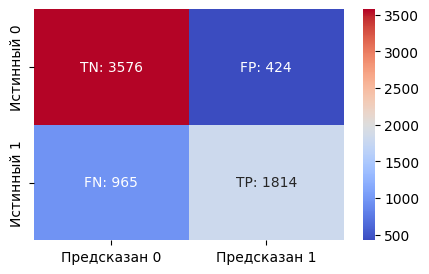

In [23]:
quality_report(transmission_valid, classifier_pt.predict(car_features_valid))

### Заключение: сравнение различных моделей классификатора  
Сравнить полученные метрики качества для классификаторов на основе модели ближайших соседей, решающего дерева и линейной (и прочих, если вы делали дополнительные задания).  
Сделать вывод.

**Здесь должен быть ваш текст!**

Сравним качество классификаторов по метрике accuracy --- точности предсказаний в целом. Для KNN и дерева возьмём метрику с вычисленным оптимальным гиперпараметром.

KNN    : 0.8436

Tree   : 0.8472

Linear : 0.7870

Как видно, наибольшую точность показала модель на основе решающего дерева, а наименьшую линейная. Дополнительно можно заметить, что линейная модель уступает другим рассмотренным вариантам, даже если взять их с параметрами по умолчанию.

### По желанию:
1. Реализовать то же самое без оболочки Perceptron, непосредственно с использованием SGDClassifier.  
Для этого разберитесь с параметрами/атрибутами/методами класса SGDClassifier (особо важные параметры loss, learning_rate, penalty, shuffle; атрибуты coef_, intercept_; метод partial_fit).  
[Описание класса SGDClassifier в документации библиотеки scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)
2. Выполните подбор функции оценки. Возможные варианты: Hinge loss (она же SVM, она же метод опорных векторов),
 log_loss (она же логистическая регрессия).
3. Построение классификатора на несколько классов.

## Часть 2. Линейная регрессия  
## Порядок работы:  
### 1. Подключение библиотек (если необходимо)

### 2. Загрузка обучающей и тестовой выборок
Если в процессе выполнения первой части работы исходный датасет был изменен, его нужно загрузить повторно.  
Если нет, этот шаг можно пропустить.

### 3. Подготовка данных для обучения и тестирования модели для задачи регрессии

**Подготовка тестовой и обучающей выборки.**  
Целевой параметр (таргет) регрессии: стоимость автомобиля.  
Исходный датасет разделить на обучающую и тестовую выборки в соотношении 80% / 20%.  
Для обеих выборок отделить целевой параметр от признаков.  

In [24]:
auto_train_set, auto_valid_set = train_test_split(df, test_size=0.2, train_size=0.8, shuffle=False)

price_train = auto_train_set['Price(euro)']
features_train = auto_train_set.drop(columns=['Price(euro)'])

price_valid = auto_valid_set['Price(euro)']
features_valid = auto_valid_set.drop(columns=['Price(euro)'])

### 4. Создание вычисляемой модели линейной регрессии на базе класса LinearRegression  
Импортировать из библиотеки соответствующий класс, создать и настроить классификатор.  
[Описание класса LinearRegression в библиотеке scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [25]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(features_train, price_train)

LinearRegression()

### 5. Оценка качества работы полученного регрессора  
#### 5.1. Вычисление метрик качества  
Для оценки качества работы регрессора определить метрики качества: среднюю абсолютную ошибку, среднюю абсолютную ошибку (в процентах), среднеквадратичную ошибку и R-квадрат (на защите работы знать смысл метрик).  
***Подсказка:*** для вычисления метрик качества модели регрессии можно использовать функции из модуля `sklearn.metrics`.  
[Описание функций вычисления метрик в библиотеке scikit-learn](https://scikit-learn.org/stable/api/sklearn.metrics.html)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

def regression_report(trained_model, features, targets):
    predictions = trained_model.predict(features)
    metrics = []
    metrics.append(mean_absolute_error(targets, predictions))
    metrics.append(mean_absolute_percentage_error(targets, predictions))
    metrics.append(mean_squared_error(targets, predictions))
    metrics.append(r2_score(targets, predictions))
    return metrics

metrics_table = pd.DataFrame(['MAE', 'MAPE', 'MSE', 'R^2'])
metrics_table = metrics_table.rename(columns={0: 'Показатель'})

metrics_table['Линейная модель'] = pd.DataFrame(regression_report(reg_model, features_valid, price_valid))
metrics_table

,Показатель,Линейная модель
0,MAE,2.505268e+03
1,MAPE,7.208589e-01
2,MSE,1.332352e+07
3,R^2,7.928419e-01


#### 5.2. Визуализация полученных ответов и невязки  
Пример приведен в ю-ноутбуке к соответствующей лекции

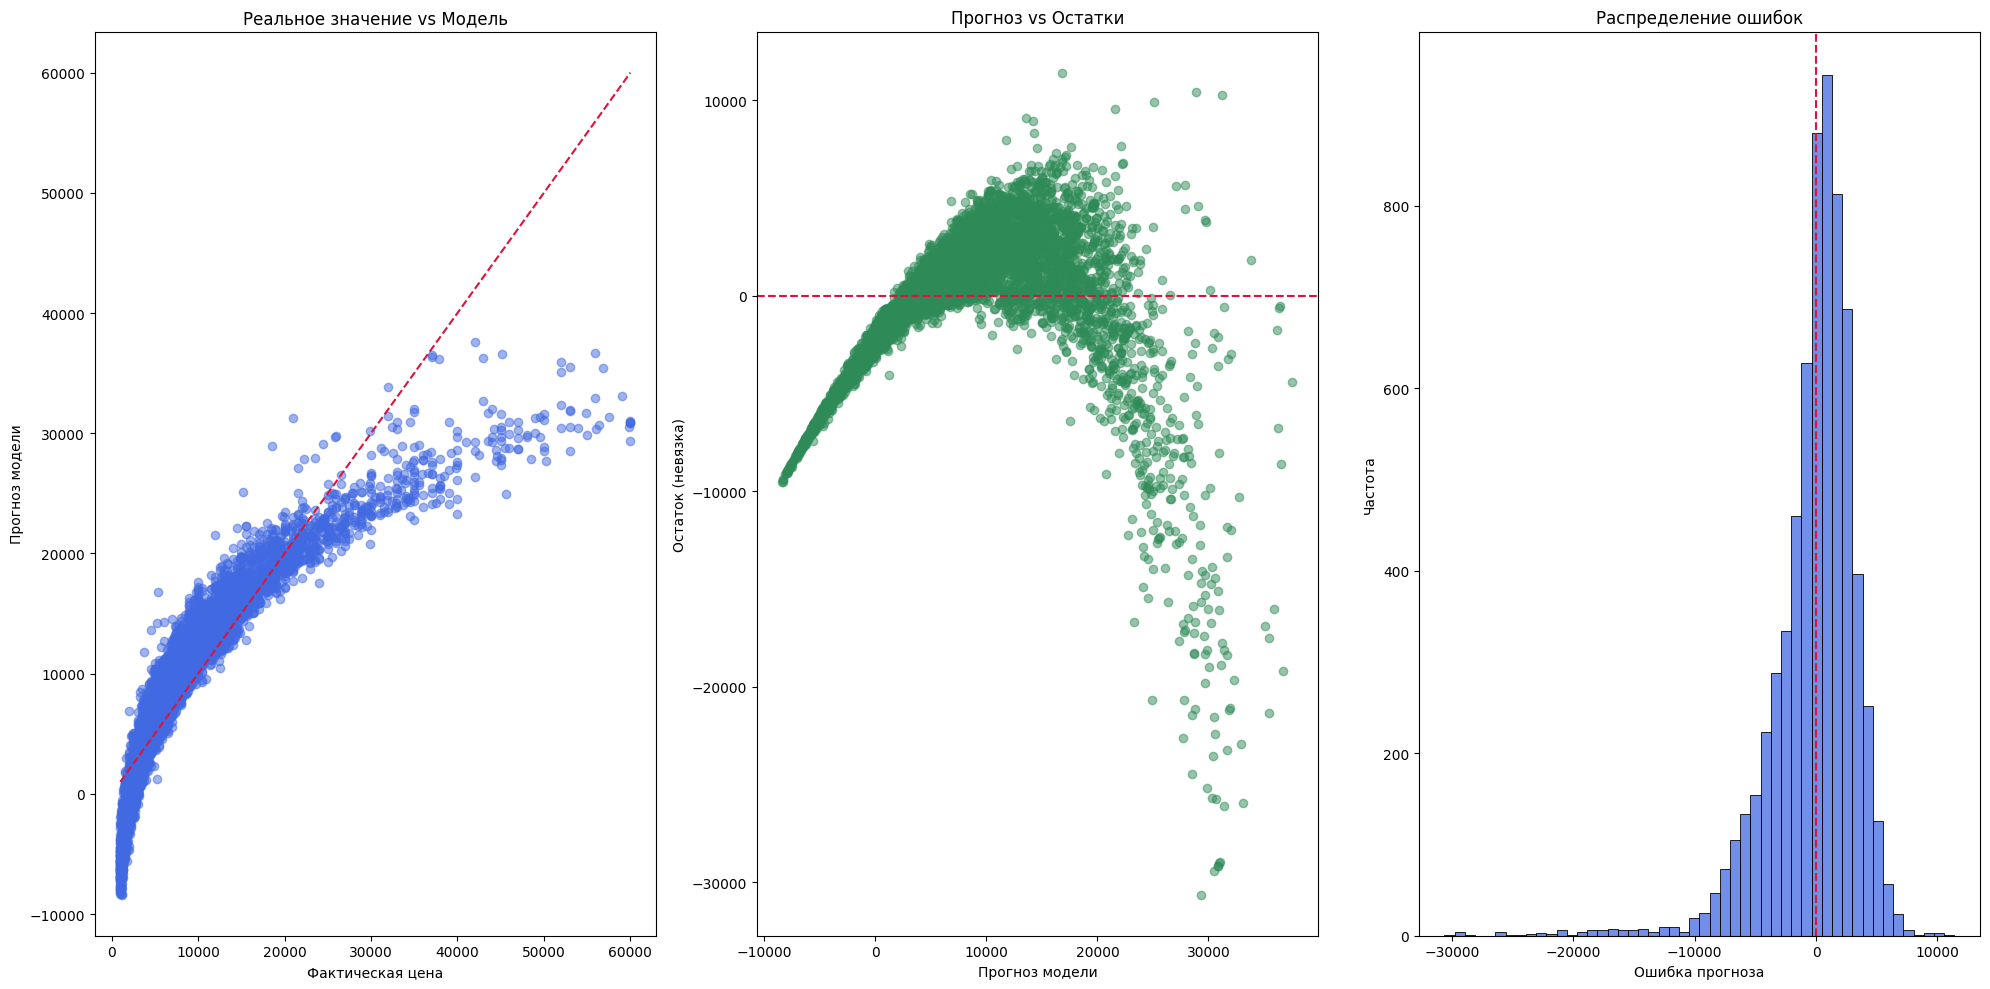

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Предсказания на валидационной части
price_forecast = reg_model.predict(features_valid)

# График 1: Реальные vs предсказанные цены
axes[0].scatter(price_valid, price_forecast, alpha=0.5, color="royalblue", label="Модельный прогноз")
axes[0].plot([min(price_valid), max(price_valid)], [min(price_valid), max(price_valid)], linestyle="--", color="crimson", label="Совпадение")
axes[0].set_xlabel("Фактическая цена")
axes[0].set_ylabel("Прогноз модели")
axes[0].set_title("Реальное значение vs Модель")

# График 2: Остатки (невязки)
residuals = price_forecast - price_valid
axes[1].scatter(price_forecast, residuals, alpha=0.5, color="seagreen")
axes[1].axhline(y=0, color="crimson", linestyle="--")
axes[1].set_xlabel("Прогноз модели")
axes[1].set_ylabel("Остаток (невязка)")
axes[1].set_title("Прогноз vs Остатки")

# График 3: Гистограмма остатков
sns.histplot(residuals, bins=50, color="royalblue", ax=axes[2])
axes[2].axvline(x=0, color="crimson", linestyle="--", label="Нулевая ошибка")
axes[2].set_xlabel("Ошибка прогноза")
axes[2].set_ylabel("Частота")
axes[2].set_title("Распределение ошибок")

plt.tight_layout()
plt.show()

### 6. Построение обучаемой модели линейной регрессии на базе класса SGDRegressor

Этот класс позволяет путем настройки параметров реализовать все линейные модели, в том числе и реализованные в виде самостоятельных классов, причем в ряде случаев более эффективно.  
[Описание класса SGDRegressor в документации библиотеки sklearn](https://scikit-learn.sourceforge.net/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor)

#### 6.1. Создание и обучение модели линейной регрессии на базе класса SGDRegressor с параметрами "по умолчанию"  
Для отслеживания динамики процесса обучения рекомендуется выводить в холде обучения краткий отчет.

In [29]:
from sklearn.linear_model import SGDRegressor
grad_descent_model = SGDRegressor()

In [31]:
grad_descent_model.fit(features_train, price_train)

SGDRegressor()

#### 6.2. Подбор параметров модели линейной регрессии на базе класса SGDRegressor и/или способов подготовки обучающей выборки  
Задача: получить показатели качества модели на базе класса SGDRegressor максимально близкие к показателям вычисляемой модели линейной линейной регрессии на базе класса LinearRegression.  
Если показатели качества модели на базе класса SGDRegressor с параметрами "по умолчанию" отличаются в худшую сторону более, чем на 5%, то необходимо
выполнить подбор параметров модели (см.
[Описание класса SGDRegressor в документации библиотеки sklearn](https://scikit-learn.sourceforge.net/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#sklearn.linear_model.SGDRegressor) ).  
Если это не поможет, возможно, потребуется провести дополнительныен мероприятия по улучшению обучающей выборки.  
В ноутбуке-отчете желательно сохранить предпринятые попытки и прописать выводы по ним.  
***Подсказка:*** Не забывайте о необходимости управлять генератором случайных чисел, если вы хотите получить повторяющиеся результаты экспериментов.

In [32]:
metrics_table['SGD (по умолчанию)'] = pd.DataFrame(regression_report(grad_descent_model, features_valid, price_valid))
metrics_table

,Показатель,Линейная модель,SGD (по умолчанию)
0,MAE,2.505268e+03,8.004506e+18
1,MAPE,7.208589e-01,2.108023e+15
2,MSE,1.332352e+07,9.056606e+37
3,R^2,7.928419e-01,-1.408149e+30


**С параметрами по умолчанию получено значительное ухудшение показателей. Попытаемся подобрать параметры лучше умолчальных.**

In [33]:
attempt_num = 1

def test_sgd_params(**params):
    global attempt_num
    custom_sgd = SGDRegressor(**params, random_state=42)
    custom_sgd.fit(features_train, price_train)
    metrics_table[f'СГД({attempt_num}-й запуск)'] = pd.DataFrame(regression_report(custom_sgd, features_valid, price_valid))
    attempt_num += 1

# Перебор различных гиперпараметров
test_sgd_params(penalty="l1")
test_sgd_params(penalty="l2")
test_sgd_params(alpha=0.1)
test_sgd_params(alpha=0.01)
test_sgd_params(alpha=0.001)
test_sgd_params(learning_rate="constant")
test_sgd_params(learning_rate="optimal")
test_sgd_params(learning_rate="invscaling")
test_sgd_params(tol=1e-2)
test_sgd_params(tol=1e-3)
test_sgd_params(tol=1e-4)
test_sgd_params(tol=1e-5)
test_sgd_params(tol=1e-6)
test_sgd_params(tol=1e-7)
test_sgd_params(tol=1e-8)
test_sgd_params(learning_rate="optimal", tol=1e-6)

metrics_table

,Показатель,Линейная модель,SGD (по умолчанию),СГД(1-й запуск),СГД(2-й запуск),СГД(3-й запуск),СГД(4-й запуск),СГД(5-й запуск),СГД(6-й запуск),СГД(7-й запуск),СГД(8-й запуск),СГД(9-й запуск),СГД(10-й запуск),СГД(11-й запуск),СГД(12-й запуск),СГД(13-й запуск),СГД(14-й запуск),СГД(15-й запуск),СГД(16-й запуск)
0,MAE,2.505268e+03,8.004506e+18,6.656791e+18,3.903496e+18,3.828482e+18,3.741129e+18,6.648711e+18,3.387425e+20,4.704933e+18,3.903496e+18,3.903496e+18,3.903496e+18,3.903496e+18,3.903496e+18,3.903496e+18,3.903496e+18,3.903496e+18,4.704933e+18
1,MAPE,7.208589e-01,2.108023e+15,1.777917e+15,1.033080e+15,9.930582e+14,9.841316e+14,1.774894e+15,8.917195e+16,1.247754e+15,1.033080e+15,1.033080e+15,1.033080e+15,1.033080e+15,1.033080e+15,1.033080e+15,1.033080e+15,1.033080e+15,1.247754e+15
2,MSE,1.332352e+07,9.056606e+37,6.350550e+37,2.160397e+37,2.042544e+37,1.977206e+37,6.333203e+37,1.621423e+41,3.149261e+37,2.160397e+37,2.160397e+37,2.160397e+37,2.160397e+37,2.160397e+37,2.160397e+37,2.160397e+37,2.160397e+37,3.149261e+37
3,R^2,7.928419e-01,-1.408149e+30,-9.874028e+29,-3.359052e+29,-3.175810e+29,-3.074219e+29,-9.847056e+29,-2.521037e+33,-4.896566e+29,-3.359052e+29,-3.359052e+29,-3.359052e+29,-3.359052e+29,-3.359052e+29,-3.359052e+29,-3.359052e+29,-3.359052e+29,-4.896566e+29


С параметрами (learning_rate="optimal", tol=1e-6) удалось добиться улучшения модели и незначительного превосходства над предоставляемой классом LinearRegression(). Остановимся на этом результате.